In [11]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

file_path = 'data/part-0.parquet'
df = pl.scan_parquet(file_path).head(1000).collect().to_pandas()
df = df.iloc[:, :20]

print("Размер датасета:", df.shape)
print("\nСписок колонок:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Размер датасета: (1000, 20)

Список колонок:
 1. inn
 2. eligible
 3. exemption_criteria
 4. filed
 5. financial
 6. simplified
 7. line_1100
 8. line_1105
 9. line_1110
10. line_1120
11. line_1130
12. line_1140
13. line_1150
14. line_1160
15. line_1170
16. line_1180
17. line_1190
18. line_1200
19. line_1210
20. line_1215


# Этап 1: Описательная статистика датасета

In [12]:
#фильтрация только числовых колонок
numeric_cols = df.select_dtypes(include=['number']).columns

description = df[numeric_cols].describe().T
description

,count,mean,std,min,25%,50%,75%,max
eligible,1000.0,1.000000,0.000000e+00,1.0,1.0,1.0,1.00,1.0
filed,1000.0,0.752000,4.320679e-01,0.0,1.0,1.0,1.00,1.0
financial,1000.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.00,0.0
simplified,788.0,0.680203,4.666940e-01,0.0,0.0,1.0,1.00,1.0
line_1100,456.0,272138.901316,3.317224e+06,0.0,0.0,823.0,9230.75,67541787.0
line_1105,6.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.00,0.0
line_1110,93.0,660.989247,3.784150e+03,0.0,0.0,0.0,0.00,35303.0
line_1120,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line_1130,21.0,27948.238095,1.280749e+05,0.0,0.0,0.0,0.00,586913.0
line_1140,19.0,5.052632,2.202391e+01,0.0,0.0,0.0,0.00,96.0


**Особенности:**
1) Колонка line_1120 полностью пустая,в ней 0 заполненных строк - её не стоит брать для графиков
2) Колонка line_1200 содержит отрицательный минимум, активы компании не могут быть отрицательными - это явная некорректность или ошибка в исходных данных
3) Среднее значение равно примерно 242 707, медиана - всего 2919, а максимум - 49 027 345, разброс данных большой

# Этап 2: Построение гистограмм и анализ выбросов

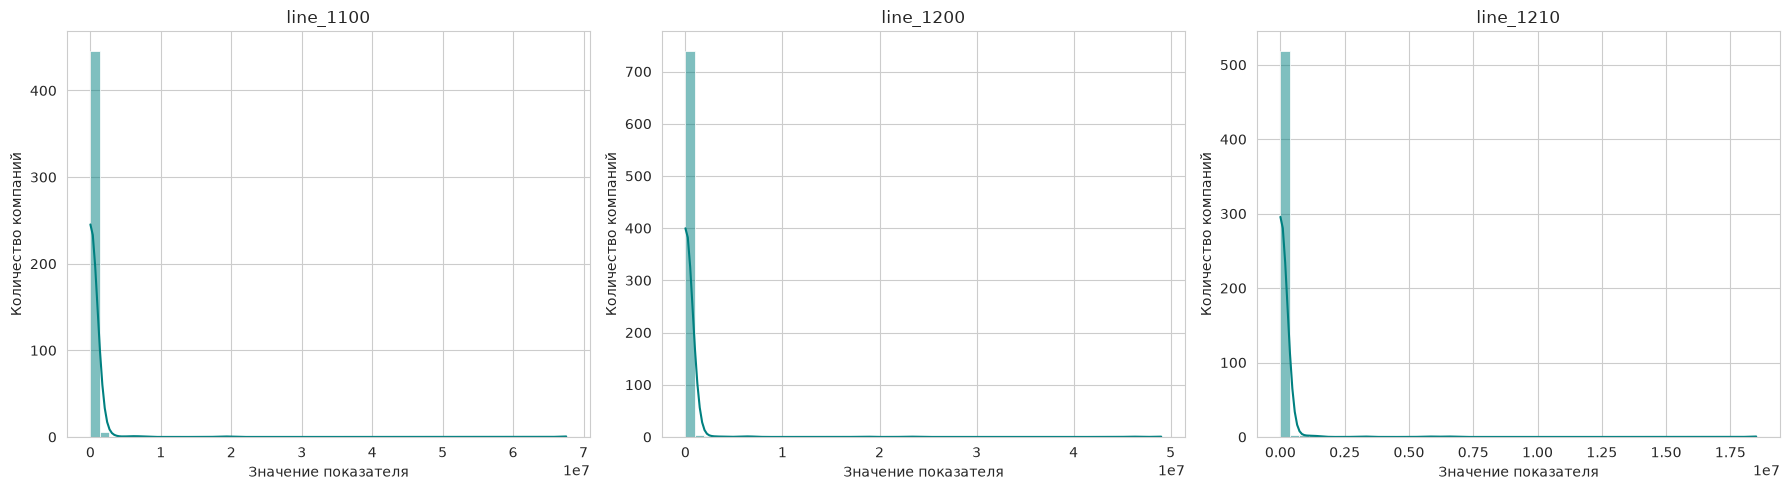

In [13]:
import numpy as np

columns_to_plot = ['line_1100', 'line_1200', 'line_1210']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(columns_to_plot):
    data_clean = df[col].dropna()
    sns.histplot(data_clean, bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Значение показателя")
    axes[i].set_ylabel("Количество компаний")

plt.tight_layout()
plt.show()

**Итог**
1. На всех трех гистограммах line_1100, line_1200, line_1210 видно, что основная масса данных в левой границе около нуля, а вдоль оси X тянется длинный пустой хвост к огромным значениям. В выборке присутствует несколько гигантских корпораций с активами до 49 млн, масштаб которых несопоставим с сотнями малых предприятий, у которых медиана активов всего около 3 тысяч
2. В описательной статистике для колонки line_1200 минимальное значение составляет `-800.0`, это явная логическая ошибка 
3. Колонка line_1120 полностью состоит из значений `NaN`, что делает её неприменимой для анализа и указывает на пропуски при формировании датасета

# Этап 3 и 4: Матрица корреляции и диаграмма рассеивания

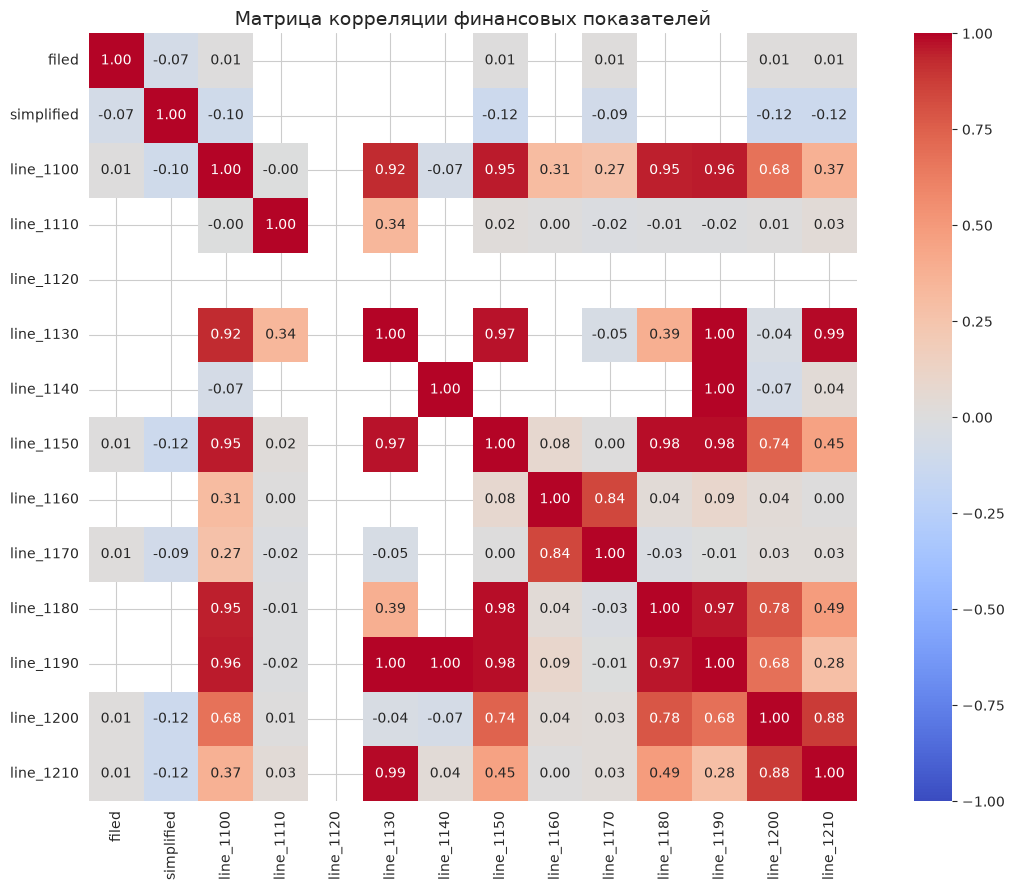

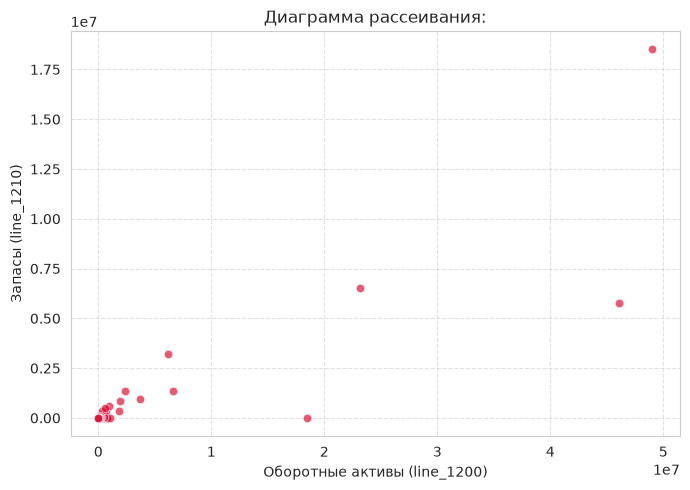

In [14]:
import numpy as np

cols_for_corr = [col for col in numeric_cols if col not in ['eligible', 'financial', 'line_1105', 'line_1215']]
corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Матрица корреляции финансовых показателей", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='line_1200', y='line_1210', alpha=0.7, color='crimson')
plt.title("Диаграмма рассеивания:", fontsize=12)
plt.xlabel("Оборотные активы (line_1200)")
plt.ylabel("Запасы (line_1210)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Итог по пункту 3 и 4**
1. Между признаками line_1200 (Оборотные активы) и line_1210 (Запасы) наблюдается сильная положительная корреляция (**0.88**)
2. Оборотные активы состоят из запасов, дебиторской задолженности, краткосрочных финансовых вложений и денежных средств и т.д. (хоть где-то бухучет пригодился). Высокая корреляция означает, что у большинства компаний в данном датасете именно запасы сырья и товаров составляют основную долю всех оборотных активов
3. Анализ диаграммы рассеивания наглядно подтверждает этот вывод. Мы видим четкий линейный тренд- с ростом по оси X (Оборотные активы) пропорционально увеличиваются значения по оси Y (Запасы). При этом точки крупных корпораций-выбросов улетают далеко в верхний правый угол, сохраняя общую линейную тенденцию

# Итоговый вывод по всей работе (Пункт 5)
**На основе проведенного экспресс-анализа выборки из 1000 строк и 20 колонок датасета RFSD можно сделать следующие выводы:**
1. Финансовые показатели компаний имеют гигантский разброс (максимумы превышают медиану в тысячи раз), что указывает на сильную неоднородность выборки, от микропредприятий до крупнейших корпораций, из-за этого стандартные гистограммы сильно сдвинуты влево
2. Выявленная высокая корреляция между оборотными активами и запасами (0.88), а также между внеоборотными активами line_1100 и основными средствами line_1150, корреляция 0.95 доказывает жесткую внутреннюю логику
3. В данных присутствуют пустые колонки line_1120 со значениями `NaN` и некорректные отрицательные значения активов - минимум `-800.0` в line_1200, что требует дополнительной предобработки перед обучением моделей машинного обучения